# 03 Component Feature Selection — Physics-Guided Jsc/Voc and All-in FF Screening

## Research question

Can compact, physically motivated feature sets retain all-in-level performance for the photovoltaic components?

## Final experimental design

1. Use **whole-dataset cross-validation only for feature interpretation and compression**.
2. For **Jsc** and **Voc**, retain the previously defined target-specific physical candidate pools:
   - Jsc: absorption, carrier generation, and carrier collection proxies.
   - Voc: bandgap ceiling and voltage-loss proxies.
3. Within those physical pools, calculate validation-fold permutation importance and retain the established **top 20** representations.
4. For **FF**, where no defensible compact physical pool was established, start from the canonical **207-feature all-in representation**, calculate validation-fold permutation importance, and inspect a new top-k compression curve.
5. Choose and freeze the FF k only after inspecting the whole-dataset CV curve.
6. Compare the frozen Jsc, Voc, and FF selected representations with the same canonical 207-feature all-in benchmark using **ten paired random 80/20 held-out splits**.

This is **not nested CV**. The feature study asks which fixed descriptors are informative and interpretable; the repeated held-out experiment asks whether those frozen representations remain comparable with all-in across random partitions. No held-out test result is used to choose k.

Excluded from this notebook: target-consistency filtering, clean/raw regimes, predicted Jsc/Voc inputs, PCE modelling, source-aware splitting, model tuning, and per-split feature reselection.


In [ ]:
# ============================================================
# 0. Imports and unified settings
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

warnings.filterwarnings("ignore")

DATA_PATH = Path("df_base.csv")
OUTPUT_DIR = Path("component_feature_selection_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Whole-dataset feature study (not a headline prediction result).
CV_SPLITS = 5
CV_RANDOM_STATE = 42
PI_REPEATS = 5
PI_TOP_N = 25

# Jsc/Voc retain the established physical-pool compression grid and k.
TOP_K_GRID = [5, 10, 15, 20, 25, 30, 35, 40]
FIXED_SELECTED_K = {"Jsc": 20, "Voc": 20}

# FF is newly screened from the canonical 207-feature all-in space.
FF_TOP_K_GRID = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 207]
#FF_SELECTED_K = 40 #None  # Set only after reviewing the FF top-k CV curve.

# Final paired prediction comparison._SIZE = 0.20

# Unified with notebooks 01 and 02.
N_ESTIMATORS = 200
MIN_SAMPLES_LEAF = 1
RF_RANDOM_STATE = 42
N_JOBS_RF = -1
N_JOBS_PI = 1  # Avoid nested parallelism; RF prediction already uses all cores.

MAX_MISSING_RATIO = 0.50
EXPECTED_ALLIN_FEATURES = 207

# FF permutation importance is required for the complete thesis run.
RUN_FF_PERMUTATION_IMPORTANCE = True

TARGETS = {
    "Jsc": "jv.default_Jsc",
    "Voc": "jv.default_Voc",
    "FF": "jv.default_FF",
}
PCE_TARGET = "jv.default_PCE"
REQUIRED_TARGETS = list(TARGETS.values()) + [PCE_TARGET]

print("Whole-dataset CV folds:", CV_SPLITS)
print("Permutation repeats:", PI_REPEATS)
print("Held-out seeds:", HOLDOUT_SEEDS)
print("RF:", N_ESTIMATORS, "trees; min_samples_leaf =", MIN_SAMPLES_LEAF)
print("FF_SELECTED_K:", FF_SELECTED_K)


Whole-dataset CV folds: 5
Permutation repeats: 5
Held-out seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
RF: 200 trees; min_samples_leaf = 1
FF_SELECTED_K: 40


## Why permutation importance rather than Random Forest impurity importance?

The default Random Forest mean-decrease-in-impurity importance is calculated from reductions in **training-set impurity** and can favour continuous variables or variables with many possible split points. That is problematic here because the representation mixes continuous descriptors with categorical material, stack, and process fields that are expanded by one-hot encoding.

Permutation importance is therefore calculated on held-out **validation folds**. Each raw input column is shuffled before the preprocessing pipeline, so the reported score drop measures the predictive contribution of the complete raw descriptor, including all one-hot levels derived from a categorical column.

The interpretation remains predictive rather than causal. Correlated descriptors can substitute for one another and therefore share or dilute permutation importance.

Reference: Strobl et al. (2007), *Bias in random forest variable importance measures*, BMC Bioinformatics 8, 25. https://doi.org/10.1186/1471-2105-8-25

In [2]:
# ============================================================
# 1. Load df_base and reproduce the common 3,953-row analysis set
# ============================================================

def resolve_data_path(filename):
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path.cwd().parent / filename,
        Path("/mnt/data") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Place df_base.csv beside this notebook "
        "or update DATA_PATH."
    )

DATA_PATH = resolve_data_path(DATA_PATH.name)
df_base = pd.read_csv(DATA_PATH, low_memory=False)
# df_base already contains the approved clean thickness, bandgap, and n_layers fields.
# The two agreed Level-3 ratios are calculated below and included in canonical all-in.

missing_targets = [c for c in REQUIRED_TARGETS if c not in df_base.columns]
if missing_targets:
    raise KeyError(f"df_base is missing required targets: {missing_targets}")

for col in REQUIRED_TARGETS:
    df_base[col] = pd.to_numeric(df_base[col], errors="coerce")

def safe_divide(numerator, denominator):
    return (numerator / denominator.replace(0, np.nan)).replace(
        [np.inf, -np.inf], np.nan
    )

# Rebuild the two agreed Level-3 descriptors used downstream and in canonical all-in.
required_thickness = {
    "PVK_thickness_clean", "ETL_thickness_clean",
    "HTL_thickness_clean", "BC_thickness_clean",
}
if required_thickness.issubset(df_base.columns):
    pvk = pd.to_numeric(df_base["PVK_thickness_clean"], errors="coerce")
    etl = pd.to_numeric(df_base["ETL_thickness_clean"], errors="coerce")
    htl = pd.to_numeric(df_base["HTL_thickness_clean"], errors="coerce")
    bc = pd.to_numeric(df_base["BC_thickness_clean"], errors="coerce")
    df_base["Absorber_to_ETL_ratio"] = safe_divide(pvk, etl)
    df_base["ff_PVK_fraction_of_total_stack"] = safe_divide(
        pvk, pvk + etl + htl + bc
    )

# Match notebook 01 and the 7/8 report: every row has Jsc, Voc, FF, and PCE.
COMMON_TARGET_MASK = df_base[REQUIRED_TARGETS].notna().all(axis=1)
df_model = df_base.loc[COMMON_TARGET_MASK].copy().reset_index(drop=True)
Y = df_model[list(TARGETS.values())].copy().reset_index(drop=True)

print("Loaded:", DATA_PATH)
print("df_base shape:", df_base.shape)
print("Common analysis rows:", len(df_model))
print("Target ranges:")
display(Y.agg(["min", "max", "mean", "std"]).T.round(4))


Loaded: df_base.csv
df_base shape: (3953, 413)
Common analysis rows: 3953
Target ranges:


,min,max,mean,std
jv.default_Jsc,0.011,29.6500,18.7675,4.6402
jv.default_Voc,0.000,1.2800,0.9780,0.1441
jv.default_FF,0.300,0.8995,0.6720,0.1039


In [3]:
# ============================================================
# 2. Build the canonical 207-feature all-in representation
# ============================================================

# Columns added during preprocessing. They are excluded from the raw candidate
# pool first; only the explicitly approved clean/helper representations are
# added back below.
PREPROCESSING_ADDED_COLUMNS = {
    "ETL_layers", "ETL_thickness_values", "ETL_n_layers", "ETL_n_thickness", "ETL_valid",
    "HTL_layers", "HTL_thickness_values", "HTL_n_layers", "HTL_n_thickness", "HTL_valid",
    "BC_layers", "BC_thickness_values", "BC_n_layers", "BC_n_thickness", "BC_valid",
    "ETL_thickness_clean", "HTL_thickness_clean", "BC_thickness_clean",
    "PVK_thickness_clean", "PVK_thickness_note", "PVK_valid",
    "all_layer_match", "perovskite_bandgap_clean", "baseline_complete",
}

# Direct targets and quantities derived from measured performance.
DIRECT_OUTCOME_COLUMNS = {
    # Default, forward, and reverse JV outcomes
    "jv.default_PCE", "jv.default_Jsc", "jv.default_Voc", "jv.default_FF",
    "jv.forward_scan_PCE", "jv.forward_scan_Jsc",
    "jv.forward_scan_Voc", "jv.forward_scan_FF",
    "jv.reverse_scan_PCE", "jv.reverse_scan_Jsc",
    "jv.reverse_scan_Voc", "jv.reverse_scan_FF",

    # Other JV results derived from the measured curve
    "jv.forward_scan_Vmp", "jv.forward_scan_Jmp",
    "jv.reverse_scan_Vmp", "jv.reverse_scan_Jmp",
    "jv.forward_scan_series_resistance",
    "jv.forward_scan_shunt_resistance",
    "jv.reverse_scan_series_resistance",
    "jv.reverse_scan_shunt_resistance",
    "jv.hysteresis_index",

    # Stabilised and EQE performance results
    "stabilised.performance_PCE", "stabilised.performance_Jsc",
    "stabilised.performance_Voc", "stabilised.performance_FF",
    "stabilised.performance_Jmp", "stabilised.performance_Vmp",
    "stabilised.performance_procedure_metrics",
    "eqe.integrated_Jsc",

    # Flags inferred from measured PCE trajectories
    "stability.PCE_burn_in_observed",
    "outdoor.PCE_burn_in_observed",
}

# Replace duplicated raw representations one-for-one with clean versions.
RAW_TO_CLEAN_REPLACEMENTS = {
    "perovskite.band_gap": "perovskite_bandgap_clean",
    "perovskite.thickness": "PVK_thickness_clean",
    "etl.thickness": "ETL_thickness_clean",
    "htl.thickness_list": "HTL_thickness_clean",
    "backcontact.thickness_list": "BC_thickness_clean",
}

LEVEL2_HELPERS = [
    "ETL_n_layers",
    "HTL_n_layers",
    "BC_n_layers",
]

LEVEL3_FEATURES = [
    "Absorber_to_ETL_ratio",
    "ff_PVK_fraction_of_total_stack",
]

# 1) Keep df_base columns with <50% NaN missingness.
# 2) Remove preprocessing-added helpers from the raw candidate pool.
# 3) Remove leakage, provenance/identity, and raw-data links.
missing_ratio = df_base.isna().mean()
eligible_raw_features = [
    column
    for column in df_base.columns
    if missing_ratio[column] < MAX_MISSING_RATIO
    and column not in PREPROCESSING_ADDED_COLUMNS
    and column not in DIRECT_OUTCOME_COLUMNS
    and column not in REQUIRED_TARGETS
    and column not in LEVEL3_FEATURES
    and column != "m_def"
    and not column.startswith("ref.")
    and not column.endswith("link_raw_data")
]

# Replace five raw duplicates, then select the approved Level-2 helpers already
# present in df_base and add the two calculated Level-3 descriptors.
ALLIN_FEATURES = [
    RAW_TO_CLEAN_REPLACEMENTS.get(column, column)
    for column in eligible_raw_features
]
ALLIN_FEATURES += LEVEL2_HELPERS + LEVEL3_FEATURES

required_added_features = (
    list(RAW_TO_CLEAN_REPLACEMENTS.values())
    + LEVEL2_HELPERS
    + LEVEL3_FEATURES
)
missing_added_features = [
    column for column in required_added_features
    if column not in df_base.columns
]
if missing_added_features:
    raise ValueError(
        "Missing canonical clean/helper/derived features in df_base: "
        + ", ".join(missing_added_features)
    )

# Fail loudly if the canonical definition changes unexpectedly.
assert len(eligible_raw_features) == 202
assert len(ALLIN_FEATURES) == EXPECTED_ALLIN_FEATURES
assert len(ALLIN_FEATURES) == len(set(ALLIN_FEATURES))
assert set(RAW_TO_CLEAN_REPLACEMENTS).isdisjoint(ALLIN_FEATURES)
assert set(RAW_TO_CLEAN_REPLACEMENTS.values()).issubset(ALLIN_FEATURES)
assert set(LEVEL2_HELPERS).issubset(ALLIN_FEATURES)
assert set(LEVEL3_FEATURES).issubset(ALLIN_FEATURES)
assert not set(ALLIN_FEATURES).intersection(DIRECT_OUTCOME_COLUMNS)
assert not any(column.startswith("ref.") for column in ALLIN_FEATURES)
assert any(column.startswith("stability.") for column in ALLIN_FEATURES)
assert any(column.startswith("outdoor.") for column in ALLIN_FEATURES)

X_ALLIN = (
    df_model[ALLIN_FEATURES]
    .replace({pd.NA: np.nan})
    .reset_index(drop=True)
)

print("All-in rows:", len(X_ALLIN))
print("Eligible raw descriptors:", len(eligible_raw_features))
print("Canonical all-in features:", X_ALLIN.shape[1])
print("Numeric:", len(X_ALLIN.select_dtypes(include=np.number).columns))
print(
    "Categorical:",
    X_ALLIN.shape[1] - len(X_ALLIN.select_dtypes(include=np.number).columns),
)
print("Level-2 helpers:", LEVEL2_HELPERS)
print("Level-3 features:", LEVEL3_FEATURES)

pd.Series(ALLIN_FEATURES, name="allin_feature").to_csv(
    OUTPUT_DIR / "allin_feature_list.csv", index=False
)


All-in rows: 3953
Eligible raw descriptors: 202
Canonical all-in features: 207
Numeric: 20
Categorical: 187
Level-2 helpers: ['ETL_n_layers', 'HTL_n_layers', 'BC_n_layers']
Level-3 features: ['Absorber_to_ETL_ratio', 'ff_PVK_fraction_of_total_stack']


## 3. Target-specific feature spaces

- **Jsc:** retain the established physics-guided candidate pool covering absorption, carrier generation, and carrier collection proxies.
- **Voc:** retain the established physics-guided candidate pool covering the bandgap ceiling and voltage-loss proxies.
- **FF:** no comparably defensible compact physical pool was established, so FF is screened from the canonical 207-feature all-in representation.

The 207-feature all-in set is the common performance benchmark for all three targets; it is not the selection pool for Jsc or Voc.


In [4]:
# ============================================================
# 3. Target-specific physical candidate pools and frozen FF useful set
# ============================================================

BASE6 = [
    "PVK_thickness_clean",
    "ETL_thickness_clean",
    "HTL_thickness_clean",
    "BC_thickness_clean",
    "perovskite_bandgap_clean",
    "Absorber_to_ETL_ratio",
]

JSC_DEVICE = [
    "cell.architecture", "cell.area_measured", "cell.flexible",
    "cell.semitransparent", "jv.light_intensity", "jv.light_spectra",
    "jv.light_source_type", "jv.light_masked_cell", "jv.scan_speed",
    "jv.test_atmosphere",
]

JSC_PROCESS = [
    "etl.deposition_procedure",
    "etl.deposition_synthesis_atmosphere",
    "etl.deposition_thermal_annealing_temperature",
    "etl.deposition_thermal_annealing_time",
    "perovskite_deposition.procedure",
    "perovskite_deposition.synthesis_atmosphere",
    "perovskite_deposition.substrate_temperature",
    "perovskite_deposition.thermal_annealing_temperature",
    "perovskite_deposition.thermal_annealing_time",
    "perovskite_deposition.quenching_induced_crystallisation",
    "htl.deposition_procedure",
    "htl.deposition_synthesis_atmosphere",
    "htl.deposition_thermal_annealing_temperature",
    "htl.deposition_thermal_annealing_time",
]

JSC_MATERIAL = [
    "cell.architecture", "etl.stack_sequence", "htl.stack_sequence",
    "backcontact.stack_sequence", "perovskite.composition_short_form",
]

VOC_DEVICE = [
    "cell.architecture", "cell.area_measured", "jv.light_intensity",
    "jv.light_spectra", "jv.light_masked_cell", "jv.scan_speed",
    "jv.test_atmosphere",
]

VOC_PROCESS = [
    "etl.deposition_procedure",
    "etl.deposition_synthesis_atmosphere",
    "etl.deposition_thermal_annealing_temperature",
    "etl.deposition_thermal_annealing_time",
    "perovskite_deposition.procedure",
    "perovskite_deposition.synthesis_atmosphere",
    "perovskite_deposition.thermal_annealing_temperature",
    "perovskite_deposition.thermal_annealing_time",
    "perovskite_deposition.quenching_induced_crystallisation",
    "perovskite_deposition.quenching_media",
    "perovskite_deposition.solvents",
    "htl.deposition_procedure",
    "htl.deposition_synthesis_atmosphere",
    "htl.deposition_thermal_annealing_temperature",
    "htl.deposition_thermal_annealing_time",
]

VOC_MATERIAL = [
    "etl.stack_sequence", "htl.stack_sequence", "backcontact.stack_sequence",
    "perovskite.composition_short_form", "perovskite.composition_a_ions",
    "perovskite.composition_b_ions", "perovskite.composition_c_ions",
    "perovskite.composition_leadfree",
]


FF_CANDIDATES = ALLIN_FEATURES.copy()

def unique_keep_order(values):
    return list(dict.fromkeys(values))

def usable_candidate_columns(proposed):
    present = [c for c in unique_keep_order(proposed) if c in df_model.columns]
    usable = [
        c for c in present
        if df_model[c].isna().mean() < MAX_MISSING_RATIO
        and df_model[c].nunique(dropna=True) > 1
    ]
    dropped = [c for c in unique_keep_order(proposed) if c not in usable]
    return usable, dropped

JSC_CANDIDATES, JSC_DROPPED = usable_candidate_columns(
    BASE6 + JSC_DEVICE + JSC_PROCESS + JSC_MATERIAL
)
VOC_CANDIDATES, VOC_DROPPED = usable_candidate_columns(
    BASE6 + VOC_DEVICE + VOC_PROCESS + VOC_MATERIAL
)

CANDIDATE_POOLS = {
    "Jsc": JSC_CANDIDATES,
    "Voc": VOC_CANDIDATES,
}

candidate_audit = pd.DataFrame([
    {
        "target": "Jsc",
        "selection_space": "Physics-guided candidate pool",
        "requested": len(unique_keep_order(BASE6 + JSC_DEVICE + JSC_PROCESS + JSC_MATERIAL)),
        "retained": len(JSC_CANDIDATES),
        "dropped": " | ".join(JSC_DROPPED),
    },
    {
        "target": "Voc",
        "selection_space": "Physics-guided candidate pool",
        "requested": len(unique_keep_order(BASE6 + VOC_DEVICE + VOC_PROCESS + VOC_MATERIAL)),
        "retained": len(VOC_CANDIDATES),
        "dropped": " | ".join(VOC_DROPPED),
    },
    {
        "target": "FF",
        "selection_space": "Canonical all-in",
        "requested": len(FF_CANDIDATES),
        "retained": len(FF_CANDIDATES),
        "dropped": "",
    },
])
display(candidate_audit)

for target, cols in CANDIDATE_POOLS.items():
    if len(cols) < FIXED_SELECTED_K[target]:
        raise ValueError(
            f"{target} has only {len(cols)} usable candidates; cannot freeze top-20."
        )

assert len(FF_CANDIDATES) == EXPECTED_ALLIN_FEATURES


,target,selection_space,requested,retained,dropped
0,Jsc,Physics-guided candidate pool,34,32,jv.light_source_type | jv.scan_speed
1,Voc,Physics-guided candidate pool,36,35,jv.scan_speed
2,FF,Canonical all-in,207,207,


In [5]:
# ============================================================
# 4. Shared preprocessing and Random Forest helpers
# ============================================================

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

def make_rf_pipeline(X, rf_random_state=RF_RANDOM_STATE):
    numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    transformers = []
    if numeric_cols:
        transformers.append((
            "numeric",
            Pipeline([("imputer", SimpleImputer(strategy="mean"))]),
            numeric_cols,
        ))
    if categorical_cols:
        transformers.append((
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("to_string", FunctionTransformer(
                    lambda x: x.astype(str), validate=False
                )),
                ("onehot", make_onehot_encoder()),
            ]),
            categorical_cols,
        ))

    preprocessor = ColumnTransformer(transformers, remainder="drop")
    model = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        random_state=rf_random_state,
        n_jobs=N_JOBS_RF,
    )
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def clean_feature_frame(frame, columns):
    return (
        frame.reindex(columns=list(columns))
        .replace({pd.NA: np.nan})
        .copy()
    )

def fit_and_score_holdout(X_train, y_train, X_test, y_test):
    model = make_rf_pipeline(X_train)
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    return {
        "Test_R2": float(r2_score(y_test, prediction)),
        "Test_RMSE": rmse(y_test, prediction),
    }


## 5. Whole-dataset CV permutation importance

Each model is fitted on four folds and permutation importance is measured on the fifth validation fold. Fold-level validation score drops are averaged.

- Jsc and Voc are ranked only within their established physics-guided candidate pools.
- FF is ranked across the canonical 207-feature all-in space.

No single 80/20 held-out test partition is used to rank features or choose k.


In [6]:
# ============================================================
# 5. Whole-dataset validation-fold permutation importance
# ============================================================

def cv_permutation_importance_raw_features(
    X,
    y,
    target_name,
    n_splits=CV_SPLITS,
    n_repeats=PI_REPEATS,
    random_state=CV_RANDOM_STATE,
):
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    importance_rows = []
    fold_score_rows = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        print(f"{target_name}: permutation fold {fold}/{n_splits}")
        X_train = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val = y.iloc[val_idx].copy()

        model = make_rf_pipeline(X_train)
        model.fit(X_train, y_train)
        val_prediction = model.predict(X_val)

        fold_score_rows.append({
            "target": target_name,
            "fold": fold,
            "Val_R2": float(r2_score(y_val, val_prediction)),
            "Val_RMSE": rmse(y_val, val_prediction),
        })

        pi = permutation_importance(
            model,
            X_val,
            y_val,
            scoring="r2",
            n_repeats=n_repeats,
            random_state=random_state + fold,
            n_jobs=N_JOBS_PI,
        )

        for feature_idx, feature in enumerate(X.columns):
            importance_rows.append({
                "target": target_name,
                "fold": fold,
                "feature": feature,
                "importance_mean": float(pi.importances_mean[feature_idx]),
                "importance_repeat_std": float(pi.importances_std[feature_idx]),
            })

    fold_importance = pd.DataFrame(importance_rows)
    fold_scores = pd.DataFrame(fold_score_rows)

    summary = (
        fold_importance
        .groupby(["target", "feature"], as_index=False)
        .agg(
            importance_mean=("importance_mean", "mean"),
            importance_fold_std=("importance_mean", "std"),
            importance_min=("importance_mean", "min"),
            importance_max=("importance_mean", "max"),
            mean_repeat_std=("importance_repeat_std", "mean"),
            n_folds=("fold", "nunique"),
        )
        .sort_values(["importance_mean", "feature"], ascending=[False, True])
        .reset_index(drop=True)
    )
    summary.insert(1, "rank", np.arange(1, len(summary) + 1))
    return summary, fold_importance, fold_scores

PI_SUMMARIES = {}
PI_FOLD_DETAILS = {}
PI_FOLD_SCORES = {}

pi_feature_spaces = {
    "Jsc": clean_feature_frame(df_model, JSC_CANDIDATES),
    "Voc": clean_feature_frame(df_model, VOC_CANDIDATES),
}
if RUN_FF_PERMUTATION_IMPORTANCE:
    pi_feature_spaces["FF"] = X_ALLIN.copy()

for target_name, X_pi in pi_feature_spaces.items():
    target_col = TARGETS[target_name]
    summary, fold_detail, fold_scores = cv_permutation_importance_raw_features(
        X_pi,
        Y[target_col],
        target_name=target_name,
    )
    PI_SUMMARIES[target_name] = summary
    PI_FOLD_DETAILS[target_name] = fold_detail
    PI_FOLD_SCORES[target_name] = fold_scores

    summary.to_csv(
        OUTPUT_DIR / f"{target_name.lower()}_cv_permutation_importance.csv",
        index=False,
    )
    fold_detail.to_csv(
        OUTPUT_DIR / f"{target_name.lower()}_cv_permutation_folds.csv",
        index=False,
    )
    fold_scores.to_csv(
        OUTPUT_DIR / f"{target_name.lower()}_cv_fold_scores.csv",
        index=False,
    )

    print(f"\n{target_name}: top permutation features")
    display(summary.head(PI_TOP_N).round(4))


Jsc: permutation fold 1/5
Jsc: permutation fold 2/5
Jsc: permutation fold 3/5
Jsc: permutation fold 4/5
Jsc: permutation fold 5/5

Jsc: top permutation features


,target,rank,feature,importance_mean,importance_fold_std,importance_min,importance_max,mean_repeat_std,n_folds
0,Jsc,1,perovskite_bandgap_clean,0.5174,0.0585,0.4555,0.6065,0.0343,5
1,Jsc,2,Absorber_to_ETL_ratio,0.1898,0.0213,0.1587,0.2158,0.0192,5
2,Jsc,3,perovskite_deposition.quenching_induced_crysta...,0.0964,0.0158,0.0831,0.1211,0.0129,5
3,Jsc,4,PVK_thickness_clean,0.0935,0.0349,0.0650,0.1532,0.0117,5
4,Jsc,5,etl.deposition_procedure,0.0372,0.0179,0.0172,0.0567,0.0087,5
5,Jsc,6,HTL_thickness_clean,0.0345,0.0107,0.0244,0.0514,0.0038,5
6,Jsc,7,perovskite.composition_short_form,0.0257,0.0071,0.0183,0.0372,0.0029,5
7,Jsc,8,htl.stack_sequence,0.0232,0.0097,0.0152,0.0354,0.0027,5
8,Jsc,9,cell.area_measured,0.0168,0.0054,0.0103,0.0226,0.0033,5
9,Jsc,10,etl.stack_sequence,0.0161,0.0236,-0.0095,0.0422,0.0028,5


Voc: permutation fold 1/5
Voc: permutation fold 2/5
Voc: permutation fold 3/5
Voc: permutation fold 4/5
Voc: permutation fold 5/5

Voc: top permutation features


,target,rank,feature,importance_mean,importance_fold_std,importance_min,importance_max,mean_repeat_std,n_folds
0,Voc,1,htl.stack_sequence,0.2438,0.0243,0.2173,0.2780,0.0347,5
1,Voc,2,Absorber_to_ETL_ratio,0.1075,0.0454,0.0344,0.1531,0.0162,5
2,Voc,3,perovskite.composition_leadfree,0.0797,0.0321,0.0361,0.1216,0.0079,5
3,Voc,4,etl.stack_sequence,0.0731,0.0717,0.0123,0.1883,0.0127,5
4,Voc,5,perovskite.composition_b_ions,0.0671,0.0334,0.0351,0.1236,0.0060,5
5,Voc,6,perovskite_deposition.solvents,0.0446,0.0053,0.0377,0.0504,0.0054,5
6,Voc,7,perovskite_deposition.quenching_media,0.0284,0.0175,0.0119,0.0554,0.0045,5
7,Voc,8,perovskite_bandgap_clean,0.0249,0.0100,0.0142,0.0371,0.0053,5
8,Voc,9,perovskite.composition_a_ions,0.0233,0.0188,0.0023,0.0521,0.0043,5
9,Voc,10,PVK_thickness_clean,0.0183,0.0111,0.0021,0.0323,0.0074,5


FF: permutation fold 1/5
FF: permutation fold 2/5
FF: permutation fold 3/5
FF: permutation fold 4/5
FF: permutation fold 5/5

FF: top permutation features


,target,rank,feature,importance_mean,importance_fold_std,importance_min,importance_max,mean_repeat_std,n_folds
0,FF,1,ff_PVK_fraction_of_total_stack,0.1572,0.0208,0.1361,0.1862,0.0190,5
1,FF,2,perovskite_deposition.solvents,0.0476,0.0190,0.0251,0.0724,0.0084,5
2,FF,3,htl.stack_sequence,0.0291,0.0059,0.0210,0.0367,0.0069,5
3,FF,4,eqe.measured,0.0200,0.0058,0.0130,0.0253,0.0081,5
4,FF,5,perovskite_deposition.synthesis_atmosphere,0.0198,0.0108,0.0079,0.0301,0.0047,5
5,FF,6,Absorber_to_ETL_ratio,0.0154,0.0084,0.0043,0.0254,0.0036,5
6,FF,7,perovskite.composition_leadfree,0.0135,0.0052,0.0093,0.0219,0.0035,5
7,FF,8,ETL_thickness_clean,0.0130,0.0012,0.0111,0.0140,0.0037,5
8,FF,9,perovskite_bandgap_clean,0.0125,0.0052,0.0047,0.0188,0.0034,5
9,FF,10,cell.area_measured,0.0120,0.0043,0.0078,0.0171,0.0036,5


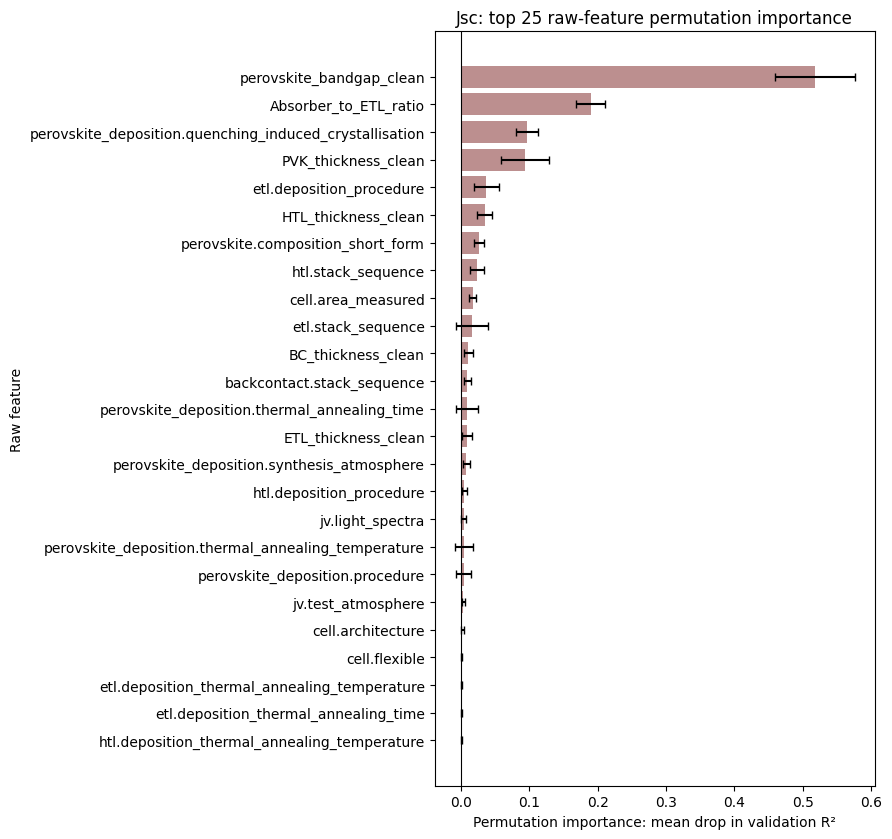

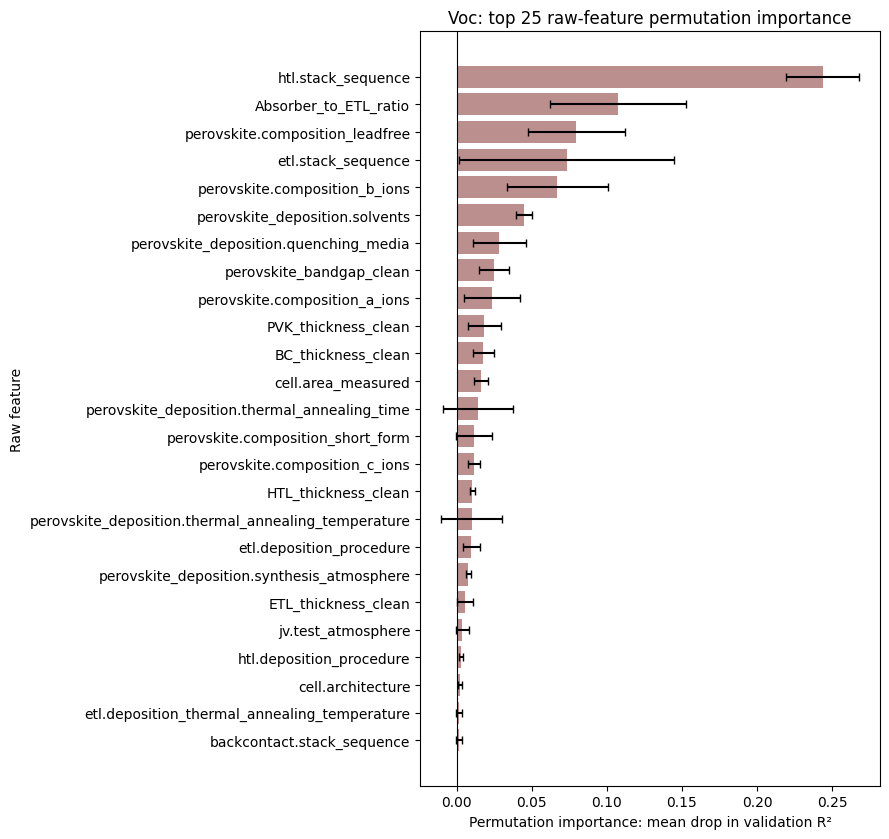

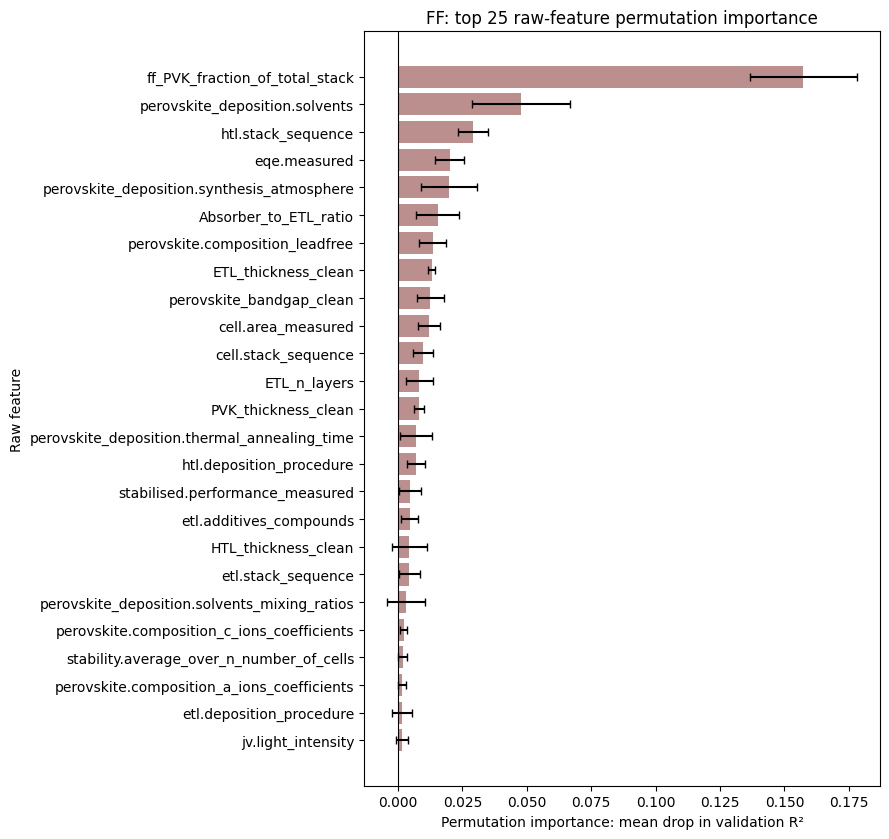

In [7]:
# ============================================================
# 6. Plot whole-dataset CV permutation importance
# ============================================================

for target_name, summary in PI_SUMMARIES.items():
    plot_df = (
        summary.head(PI_TOP_N)
        .sort_values("importance_mean", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(9, max(5, 0.34 * len(plot_df))))
    ax.barh(
        plot_df["feature"],
        plot_df["importance_mean"],
        xerr=plot_df["importance_fold_std"],
        capsize=3,
        color="rosybrown",
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Permutation importance: mean drop in validation R²")
    ax.set_ylabel("Raw feature")
    ax.set_title(f"{target_name}: top {PI_TOP_N} raw-feature permutation importance")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{target_name.lower()}_cv_permutation_importance.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 7. Whole-dataset top-k compression curves

The Jsc and Voc rankings remain restricted to their physics-guided candidate pools. Their established **k = 20** representations are retained.

FF is newly ranked from the canonical 207-feature all-in space. Its wider top-k curve must be inspected before choosing `FF_SELECTED_K`. Select the smallest defensible k near the performance plateau; do not use the ten held-out results to choose it.


Jsc: top-5 CV curve
Jsc: top-10 CV curve
Jsc: top-15 CV curve
Jsc: top-20 CV curve
Jsc: top-25 CV curve
Jsc: top-30 CV curve
Jsc: top-32 CV curve


,target,k,CV_R2,CV_RMSE
0,Jsc,5,0.5934,2.9586
1,Jsc,10,0.6497,2.7458
2,Jsc,15,0.6566,2.7188
3,Jsc,20,0.6595,2.7071
4,Jsc,25,0.6588,2.7100
5,Jsc,30,0.6589,2.7096
6,Jsc,32,0.6588,2.7100


Jsc frozen top-20:


,selected_feature
0,perovskite_bandgap_clean
1,Absorber_to_ETL_ratio
2,perovskite_deposition.quenching_induced_crysta...
3,PVK_thickness_clean
4,etl.deposition_procedure
5,HTL_thickness_clean
6,perovskite.composition_short_form
7,htl.stack_sequence
8,cell.area_measured
9,etl.stack_sequence


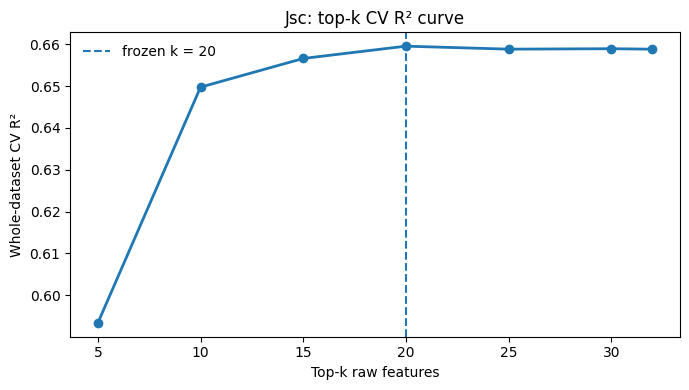

Voc: top-5 CV curve
Voc: top-10 CV curve
Voc: top-15 CV curve
Voc: top-20 CV curve
Voc: top-25 CV curve
Voc: top-30 CV curve
Voc: top-35 CV curve


,target,k,CV_R2,CV_RMSE
0,Voc,5,0.5326,0.0985
1,Voc,10,0.6243,0.0883
2,Voc,15,0.6213,0.0887
3,Voc,20,0.6327,0.0873
4,Voc,25,0.6342,0.0871
5,Voc,30,0.6342,0.0871
6,Voc,35,0.6329,0.0873


Voc frozen top-20:


,selected_feature
0,htl.stack_sequence
1,Absorber_to_ETL_ratio
2,perovskite.composition_leadfree
3,etl.stack_sequence
4,perovskite.composition_b_ions
5,perovskite_deposition.solvents
6,perovskite_deposition.quenching_media
7,perovskite_bandgap_clean
8,perovskite.composition_a_ions
9,PVK_thickness_clean


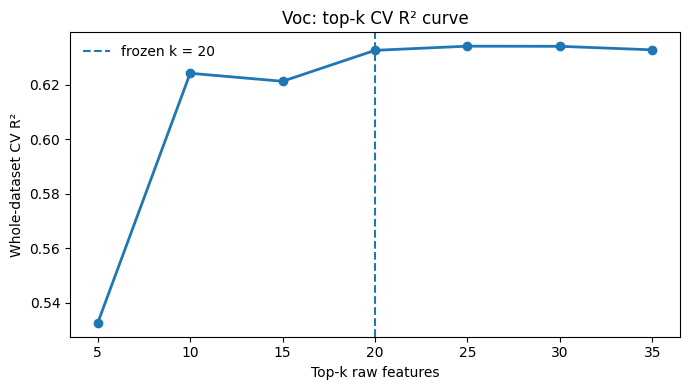

FF: top-5 CV curve
FF: top-10 CV curve
FF: top-15 CV curve
FF: top-20 CV curve
FF: top-25 CV curve
FF: top-30 CV curve
FF: top-40 CV curve
FF: top-50 CV curve
FF: top-75 CV curve
FF: top-100 CV curve
FF: top-150 CV curve
FF: top-207 CV curve


,target,k,CV_R2,CV_RMSE
0,FF,5,0.3617,0.0830
1,FF,10,0.4272,0.0786
2,FF,15,0.4634,0.0761
3,FF,20,0.4700,0.0756
4,FF,25,0.4752,0.0752
5,FF,30,0.4795,0.0749
6,FF,40,0.4820,0.0748
7,FF,50,0.4832,0.0747
8,FF,75,0.4839,0.0746
9,FF,100,0.4843,0.0746


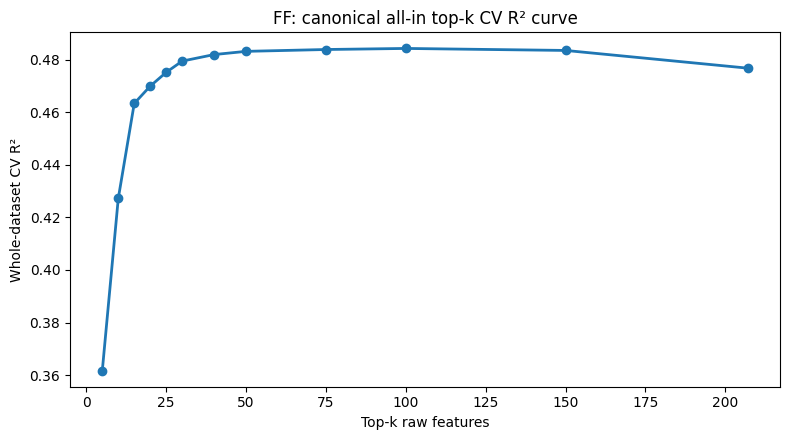


STOP AFTER REVIEWING THE FF CURVE. Choose FF_SELECTED_K in the settings cell, then rerun this cell before running the held-out section.


In [8]:
# ============================================================
# 7. Whole-dataset CV top-k curves and fixed selected sets
# ============================================================

def whole_dataset_topk_curve(
    X,
    y,
    ranked_features,
    target_name,
    k_grid,
):
    max_k = len(ranked_features)
    k_values = [k for k in k_grid if k <= max_k]
    k_values = sorted(set(k_values + [max_k]))
    rows = []

    for k in k_values:
        print(f"{target_name}: top-{k} CV curve")
        columns = ranked_features[:k]
        X_k = X[columns].copy()
        cv = KFold(
            n_splits=CV_SPLITS,
            shuffle=True,
            random_state=CV_RANDOM_STATE,
        )
        model = make_rf_pipeline(X_k)
        prediction = cross_val_predict(
            model,
            X_k,
            y,
            cv=cv,
            n_jobs=1,
        )
        rows.append({
            "target": target_name,
            "k": k,
            "CV_R2": float(r2_score(y, prediction)),
            "CV_RMSE": rmse(y, prediction),
        })
    return pd.DataFrame(rows)

TOPK_CURVES = {}
SELECTED_FEATURES = {}

# Jsc and Voc: unchanged physics-guided selection logic.
for target_name in ["Jsc", "Voc"]:
    ranking = PI_SUMMARIES[target_name]["feature"].tolist()
    X_candidate = clean_feature_frame(df_model, CANDIDATE_POOLS[target_name])
    y_target = Y[TARGETS[target_name]].reset_index(drop=True)

    curve = whole_dataset_topk_curve(
        X_candidate,
        y_target,
        ranking,
        target_name,
        TOP_K_GRID,
    )
    TOPK_CURVES[target_name] = curve
    selected_k = FIXED_SELECTED_K[target_name]
    SELECTED_FEATURES[target_name] = ranking[:selected_k]

    curve.to_csv(
        OUTPUT_DIR / f"{target_name.lower()}_whole_dataset_topk_curve.csv",
        index=False,
    )
    pd.Series(
        SELECTED_FEATURES[target_name], name="selected_feature"
    ).to_csv(
        OUTPUT_DIR / f"{target_name.lower()}_selected_top20.csv",
        index=False,
    )

    display(curve.round(4))
    print(f"{target_name} frozen top-{selected_k}:")
    display(pd.DataFrame({"selected_feature": SELECTED_FEATURES[target_name]}))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(curve["k"], curve["CV_R2"], marker="o", linewidth=2)
    ax.axvline(
        selected_k,
        color="tab:blue",
        linestyle="--",
        label=f"frozen k = {selected_k}",
    )
    ax.set_xlabel("Top-k raw features")
    ax.set_ylabel("Whole-dataset CV R²")
    ax.set_title(f"{target_name}: top-k CV R² curve")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{target_name.lower()}_whole_dataset_topk_curve.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

# FF: new selection study from canonical 207-feature all-in.
if "FF" not in PI_SUMMARIES:
    raise RuntimeError(
        "FF permutation importance has not been run. "
        "Set RUN_FF_PERMUTATION_IMPORTANCE=True and run Section 5."
    )

ff_ranking = PI_SUMMARIES["FF"]["feature"].tolist()
ff_curve = whole_dataset_topk_curve(
    X_ALLIN,
    Y[TARGETS["FF"]].reset_index(drop=True),
    ff_ranking,
    "FF",
    FF_TOP_K_GRID,
)
TOPK_CURVES["FF"] = ff_curve
ff_curve.to_csv(
    OUTPUT_DIR / "ff_whole_dataset_topk_curve.csv",
    index=False,
)

display(ff_curve.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ff_curve["k"], ff_curve["CV_R2"], marker="o", linewidth=2)
if FF_SELECTED_K is not None:
    ax.axvline(
        FF_SELECTED_K,
        color="tab:blue",
        linestyle="--",
        label=f"frozen k = {FF_SELECTED_K}",
    )
    ax.legend(frameon=False)
ax.set_xlabel("Top-k raw features")
ax.set_ylabel("Whole-dataset CV R²")
ax.set_title("FF: canonical all-in top-k CV R² curve")
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "ff_whole_dataset_topk_curve.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

if FF_SELECTED_K is None:
    print(
        "\nSTOP AFTER REVIEWING THE FF CURVE. "
        "Choose FF_SELECTED_K in the settings cell, then rerun this cell "
        "before running the held-out section."
    )
else:
    if not 1 <= FF_SELECTED_K <= len(ff_ranking):
        raise ValueError(
            f"FF_SELECTED_K must be between 1 and {len(ff_ranking)}."
        )
    SELECTED_FEATURES["FF"] = ff_ranking[:FF_SELECTED_K]
    pd.Series(
        SELECTED_FEATURES["FF"], name="selected_feature"
    ).to_csv(
        OUTPUT_DIR / f"ff_selected_top{FF_SELECTED_K}.csv",
        index=False,
    )
    print(f"FF frozen top-{FF_SELECTED_K}:")
    display(pd.DataFrame({"selected_feature": SELECTED_FEATURES["FF"]}))

selected_features_for_export = {
    "Jsc": SELECTED_FEATURES["Jsc"],
    "Voc": SELECTED_FEATURES["Voc"],
    "FF": SELECTED_FEATURES.get("FF"),
}
with open(OUTPUT_DIR / "selected_features.json", "w", encoding="utf-8") as handle:
    json.dump(selected_features_for_export, handle, indent=2)


In [14]:
FF_SELECTED_K = 40

ff_ranking = PI_SUMMARIES["FF"]["feature"].tolist()
SELECTED_FEATURES["FF"] = ff_ranking[:FF_SELECTED_K]

pd.Series(
    SELECTED_FEATURES["FF"],
    name="selected_feature",
).to_csv(
    OUTPUT_DIR / "ff_selected_top40.csv",
    index=False,
)

print("FF selected features:", len(SELECTED_FEATURES["FF"]))

FF selected features: 40


## 8. Ten paired 80/20 held-out comparisons

Run this section only after `FF_SELECTED_K` has been chosen from the whole-dataset FF top-k curve and the selected FF list has been frozen.

For each seed, selected and all-in models use the same train and test rows. No feature ranking, feature selection, or choice of k occurs inside these splits.

- Jsc: selected 20 vs canonical all-in 207
- Voc: selected 20 vs canonical all-in 207
- FF: selected k vs canonical all-in 207


In [15]:
# ============================================================
# 8. Paired repeated held-out evaluation
# ============================================================

if FF_SELECTED_K is None or "FF" not in SELECTED_FEATURES:
    raise ValueError(
        "FF selection is not frozen. Review the FF top-k CV curve, set "
        "FF_SELECTED_K in the settings cell, and rerun Section 7 first."
    )

FEATURE_SETS = {
    "Jsc": {
        "Selected 20": SELECTED_FEATURES["Jsc"],
        "All-in": ALLIN_FEATURES,
    },
    "Voc": {
        "Selected 20": SELECTED_FEATURES["Voc"],
        "All-in": ALLIN_FEATURES,
    },
    "FF": {
        f"Selected {FF_SELECTED_K}": SELECTED_FEATURES["FF"],
        "All-in": ALLIN_FEATURES,
    },
}

all_indices = np.arange(len(df_model))
heldout_rows = []

for split_seed in HOLDOUT_SEEDS:
    train_idx, test_idx = train_test_split(
        all_indices,
        test_size=TEST_SIZE,
        random_state=split_seed,
        shuffle=True,
    )

    for target_name, target_col in TARGETS.items():
        y_train = Y[target_col].iloc[train_idx].reset_index(drop=True)
        y_test = Y[target_col].iloc[test_idx].reset_index(drop=True)

        for feature_set_name, feature_cols in FEATURE_SETS[target_name].items():
            X_target = clean_feature_frame(df_model, feature_cols)
            X_train = X_target.iloc[train_idx].reset_index(drop=True)
            X_test = X_target.iloc[test_idx].reset_index(drop=True)

            scores = fit_and_score_holdout(
                X_train, y_train, X_test, y_test
            )
            heldout_rows.append({
                "target": target_name,
                "target_column": target_col,
                "split_seed": split_seed,
                "feature_set": feature_set_name,
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                "n_raw_features": len(feature_cols),
                **scores,
            })

            print(
                f"seed={split_seed} | {target_name:>3} | "
                f"{feature_set_name:<11} | R2={scores['Test_R2']:.4f} | "
                f"RMSE={scores['Test_RMSE']:.4f}"
            )

    # Checkpoint after each complete paired split.
    pd.DataFrame(heldout_rows).to_csv(
        OUTPUT_DIR / "component_heldout_results_by_seed_PARTIAL.csv",
        index=False,
    )

COMPONENT_HELDOUT_RESULTS = pd.DataFrame(heldout_rows)
COMPONENT_HELDOUT_RESULTS.to_csv(
    OUTPUT_DIR / "component_heldout_results_by_seed.csv",
    index=False,
)

print("Completed rows:", len(COMPONENT_HELDOUT_RESULTS))


seed=0 | Jsc | Selected 20 | R2=0.6888 | RMSE=2.5823
seed=0 | Jsc | All-in      | R2=0.6624 | RMSE=2.6897
seed=0 | Voc | Selected 20 | R2=0.5792 | RMSE=0.0897
seed=0 | Voc | All-in      | R2=0.5832 | RMSE=0.0893
seed=0 |  FF | Selected 40 | R2=0.5113 | RMSE=0.0724
seed=0 |  FF | All-in      | R2=0.5130 | RMSE=0.0723
seed=1 | Jsc | Selected 20 | R2=0.6016 | RMSE=3.0234
seed=1 | Jsc | All-in      | R2=0.6067 | RMSE=3.0042
seed=1 | Voc | Selected 20 | R2=0.5880 | RMSE=0.0985
seed=1 | Voc | All-in      | R2=0.5911 | RMSE=0.0981
seed=1 |  FF | Selected 40 | R2=0.4102 | RMSE=0.0803
seed=1 |  FF | All-in      | R2=0.4162 | RMSE=0.0799
seed=2 | Jsc | Selected 20 | R2=0.6581 | RMSE=2.7924
seed=2 | Jsc | All-in      | R2=0.6457 | RMSE=2.8426
seed=2 | Voc | Selected 20 | R2=0.5802 | RMSE=0.1011
seed=2 | Voc | All-in      | R2=0.5581 | RMSE=0.1037
seed=2 |  FF | Selected 40 | R2=0.4865 | RMSE=0.0760
seed=2 |  FF | All-in      | R2=0.4757 | RMSE=0.0768
seed=3 | Jsc | Selected 20 | R2=0.6550 | RMSE=

In [16]:
# ============================================================
# 9. Final mean ± std and paired deltas
# ============================================================

COMPONENT_HELDOUT_SUMMARY = (
    COMPONENT_HELDOUT_RESULTS
    .groupby(["target", "feature_set"], as_index=False)
    .agg(
        n_splits=("split_seed", "nunique"),
        n_raw_features=("n_raw_features", "first"),
        Test_R2_mean=("Test_R2", "mean"),
        Test_R2_std=("Test_R2", "std"),
        Test_R2_min=("Test_R2", "min"),
        Test_R2_max=("Test_R2", "max"),
        Test_RMSE_mean=("Test_RMSE", "mean"),
        Test_RMSE_std=("Test_RMSE", "std"),
        Test_RMSE_min=("Test_RMSE", "min"),
        Test_RMSE_max=("Test_RMSE", "max"),
    )
    .sort_values(["target", "feature_set"])
    .reset_index(drop=True)
)

display(COMPONENT_HELDOUT_SUMMARY.round(4))
COMPONENT_HELDOUT_SUMMARY.to_csv(
    OUTPUT_DIR / "component_heldout_summary.csv", index=False
)

allin_rows = (
    COMPONENT_HELDOUT_RESULTS.loc[
        COMPONENT_HELDOUT_RESULTS["feature_set"] == "All-in",
        ["target", "split_seed", "Test_R2", "Test_RMSE"],
    ]
    .rename(columns={
        "Test_R2": "Test_R2_Allin",
        "Test_RMSE": "Test_RMSE_Allin",
    })
)
selected_rows = (
    COMPONENT_HELDOUT_RESULTS.loc[
        COMPONENT_HELDOUT_RESULTS["feature_set"] != "All-in",
        ["target", "split_seed", "feature_set", "Test_R2", "Test_RMSE"],
    ]
    .rename(columns={
        "Test_R2": "Test_R2_Selected",
        "Test_RMSE": "Test_RMSE_Selected",
    })
)
paired = selected_rows.merge(
    allin_rows,
    on=["target", "split_seed"],
    how="inner",
    validate="one_to_one",
)
paired["Delta_R2_Selected_minus_Allin"] = (
    paired["Test_R2_Selected"] - paired["Test_R2_Allin"]
)
paired["Delta_RMSE_Selected_minus_Allin"] = (
    paired["Test_RMSE_Selected"] - paired["Test_RMSE_Allin"]
)

COMPONENT_PAIRED_SUMMARY = (
    paired
    .groupby("target", as_index=False)
    .agg(
        n_splits=("split_seed", "nunique"),
        Delta_R2_mean=("Delta_R2_Selected_minus_Allin", "mean"),
        Delta_R2_std=("Delta_R2_Selected_minus_Allin", "std"),
        Delta_RMSE_mean=("Delta_RMSE_Selected_minus_Allin", "mean"),
        Delta_RMSE_std=("Delta_RMSE_Selected_minus_Allin", "std"),
        selected_wins_R2=(
            "Delta_R2_Selected_minus_Allin", lambda values: int((values > 0).sum())
        ),
    )
)

display(COMPONENT_PAIRED_SUMMARY.round(4))
paired.to_csv(OUTPUT_DIR / "component_paired_results_by_seed.csv", index=False)
COMPONENT_PAIRED_SUMMARY.to_csv(
    OUTPUT_DIR / "component_paired_summary.csv", index=False
)


,target,feature_set,n_splits,n_raw_features,Test_R2_mean,Test_R2_std,Test_R2_min,Test_R2_max,Test_RMSE_mean,Test_RMSE_std,Test_RMSE_min,Test_RMSE_max
0,FF,All-in,10,207,0.4885,0.0297,0.4162,0.5207,0.0744,0.0028,0.0697,0.0799
1,FF,Selected 40,10,40,0.4879,0.0315,0.4102,0.5214,0.0744,0.0028,0.0695,0.0803
2,Jsc,All-in,10,207,0.6454,0.0332,0.6042,0.7082,2.7461,0.1613,2.4643,3.0042
3,Jsc,Selected 20,10,20,0.6533,0.0330,0.6016,0.7103,2.7151,0.1598,2.4556,3.0234
4,Voc,All-in,10,207,0.6221,0.0616,0.5387,0.7230,0.0909,0.0085,0.0793,0.1037
5,Voc,Selected 20,10,20,0.6241,0.0527,0.5735,0.7080,0.0907,0.0075,0.0795,0.1011


,target,n_splits,Delta_R2_mean,Delta_R2_std,Delta_RMSE_mean,Delta_RMSE_std,selected_wins_R2
0,FF,10,-0.0006,0.0055,0.0000,0.0004,5
1,Jsc,10,0.0079,0.0101,-0.0310,0.0401,8
2,Voc,10,0.0020,0.0152,-0.0002,0.0018,4


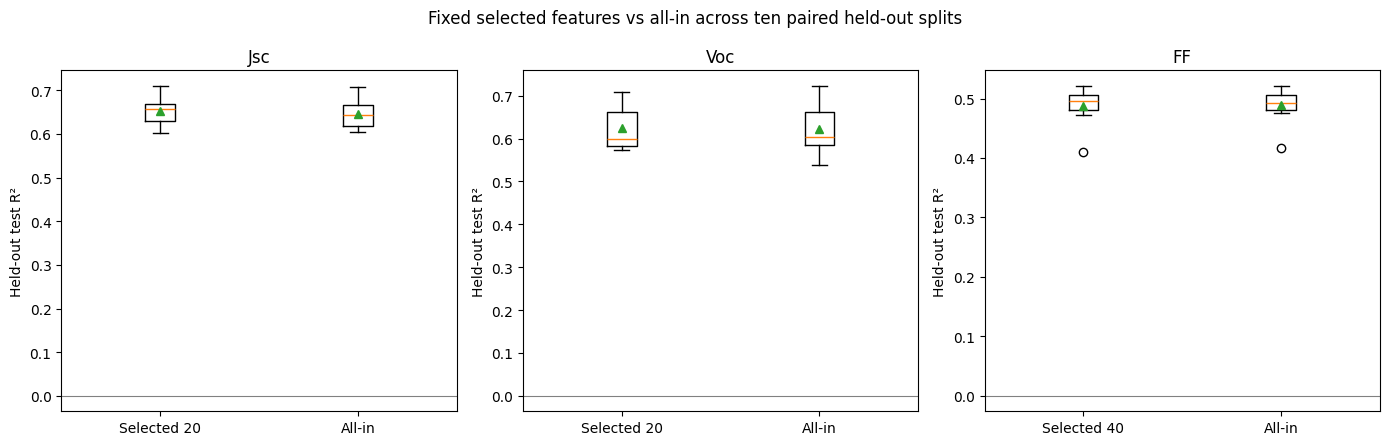

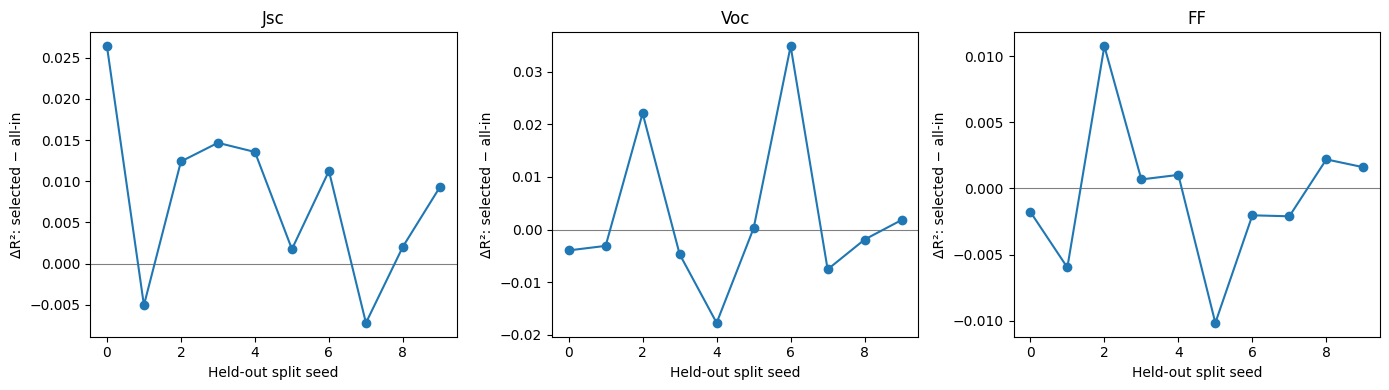

In [17]:
# ============================================================
# 10. Thesis-facing held-out comparison figures
# ============================================================

target_order = ["Jsc", "Voc", "FF"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, target_name in zip(axes, target_order):
    selected_label = f"Selected {FF_SELECTED_K}" if target_name == "FF" else "Selected 20"
    feature_order = [selected_label, "All-in"]
    plot_data = [
        COMPONENT_HELDOUT_RESULTS.loc[
            (COMPONENT_HELDOUT_RESULTS["target"] == target_name)
            & (COMPONENT_HELDOUT_RESULTS["feature_set"] == feature_set),
            "Test_R2",
        ].values
        for feature_set in feature_order
    ]
    ax.boxplot(plot_data, tick_labels=feature_order, showmeans=True)
    ax.set_title(target_name)
    ax.set_ylabel("Held-out test R²")
    ax.axhline(0, color="grey", linewidth=0.8)

fig.suptitle("Fixed selected features vs all-in across ten paired held-out splits")
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "component_selected_vs_allin_heldout_r2.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Direct paired difference by seed for all three component targets.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, target_name in zip(axes, target_order):
    target_pair = paired[paired["target"] == target_name].sort_values("split_seed")
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.plot(
        target_pair["split_seed"],
        target_pair["Delta_R2_Selected_minus_Allin"],
        marker="o",
    )
    ax.set_title(target_name)
    ax.set_xlabel("Held-out split seed")
    ax.set_ylabel("ΔR²: selected − all-in")

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "component_paired_delta_r2_by_seed.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## Interpretation carried into the thesis

- Validation-fold permutation importance is used instead of Random Forest impurity importance because the latter is training-derived and can be biased by feature type/cardinality.
- Jsc and Voc use target-specific, physics-guided candidate pools; the all-in representation is their benchmark, not their selection pool.
- The Jsc and Voc top-20 sets retain the established absorption/generation/collection and bandgap/loss-proxy logic.
- FF is screened from the canonical 207-feature all-in space because no equally defensible compact physical candidate pool was established.
- The FF top-k curve is a whole-dataset CV compression study; FF k must be frozen before the ten held-out comparisons.
- The ten held-out splits assess the stability of the **fixed representations**, not an automatically reselected feature pipeline.
- Selected and all-in comparisons are paired by split seed, so their differences are not confounded by different test partitions.
- FF remains proxy-based because the dataset lacks direct mobility, resistance, trap-density, interface-quality, and morphology descriptors.
- Permutation importance measures predictive contribution, not causality; correlated features can share importance.
